# Bayesian Inference & MCMC: Change Point Detection Demo

## 🎯 What You'll Learn

This notebook teaches **Bayesian inference** and **Markov Chain Monte Carlo (MCMC)** using a simple, practical example:

- **The Problem**: Find when a price "jumped" from one level to another (a change point)
- **The Method**: Use Bayesian inference to estimate the change point and price levels
- **The Tool**: MCMC sampling to approximate the posterior distribution

### Why This Matters

Real-world time series (like oil prices, stock markets, or sensor data) often have **regime shifts** caused by events like:
- Supply disruptions
- Policy changes
- Market shocks

Bayesian methods let us **quantify uncertainty** about when and how these shifts happened.

---
## 📦 Setup & Imports

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az

from src.demo_data import generate_synthetic_prices, generate_events, save_data
from src.plots import (
    plot_price_with_changepoint,
    plot_price_with_events,
    plot_posterior_tau,
    plot_posterior_means,
    plot_trace_summary
)

print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")

az.style.use("arviz-darkgrid")

/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/.venv/lib/python3.14/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


PyMC version: 5.27.1
ArviZ version: 0.23.3


---
## 📊 Step 1: Generate Synthetic Data

We'll create a **synthetic price time series** that mimics oil prices:
- ~400 days of daily prices
- Prices start around **$30** (low regime)
- At some point, they jump to **$60** (high regime)
- Random noise makes it realistic

We also generate an **events table** with 2-3 events (one near the true change point).

In [2]:
prices_df, tau_true = generate_synthetic_prices(
    n_days=400,
    mu1_true=30,
    mu2_true=60,
    sigma_true=3.5,
    tau_true_pct=0.5,
    seed=42
)

events_df = generate_events(tau_true, n_days=400, seed=42)

print(f"\n✓ Generated {len(prices_df)} days of price data")
print(f"✓ True change point: day {tau_true} ({prices_df.loc[tau_true, 'date'].date()})")
print(f"✓ Generated {len(events_df)} events\n")

print("First few rows of price data:")
print(prices_df.head())

print("\nEvents:")
print(events_df)


✓ Generated 400 days of price data
✓ True change point: day 200 (2023-07-20)
✓ Generated 3 events

First few rows of price data:
        date      price
0 2023-01-01  31.738500
1 2023-01-02  29.516075
2 2023-01-03  32.266910
3 2023-01-04  35.330604
4 2023-01-05  29.180463

Events:
                event_name start_date   end_date      category
0  Major Supply Disruption 2023-07-10 2023-07-30  supply_shock
1      Policy Announcement 2023-04-09 2023-04-14        policy
2        Market Correction 2023-09-18 2023-09-25        market


### Save Data to CSV

In [3]:
import os
os.makedirs('../data', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

prices_df.to_csv('../data/demo_prices.csv', index=False)
events_df.to_csv('../data/demo_events.csv', index=False)

print("✓ Saved demo_prices.csv and demo_events.csv to data/")

✓ Saved demo_prices.csv and demo_events.csv to data/


---
## 📈 Step 2: Visualize the Data

Let's look at the price time series with the **true change point** (which we know, but the model doesn't!).

/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/notebooks/../src/plots.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


✓ Saved: ../outputs/01_price_with_true_changepoint.png


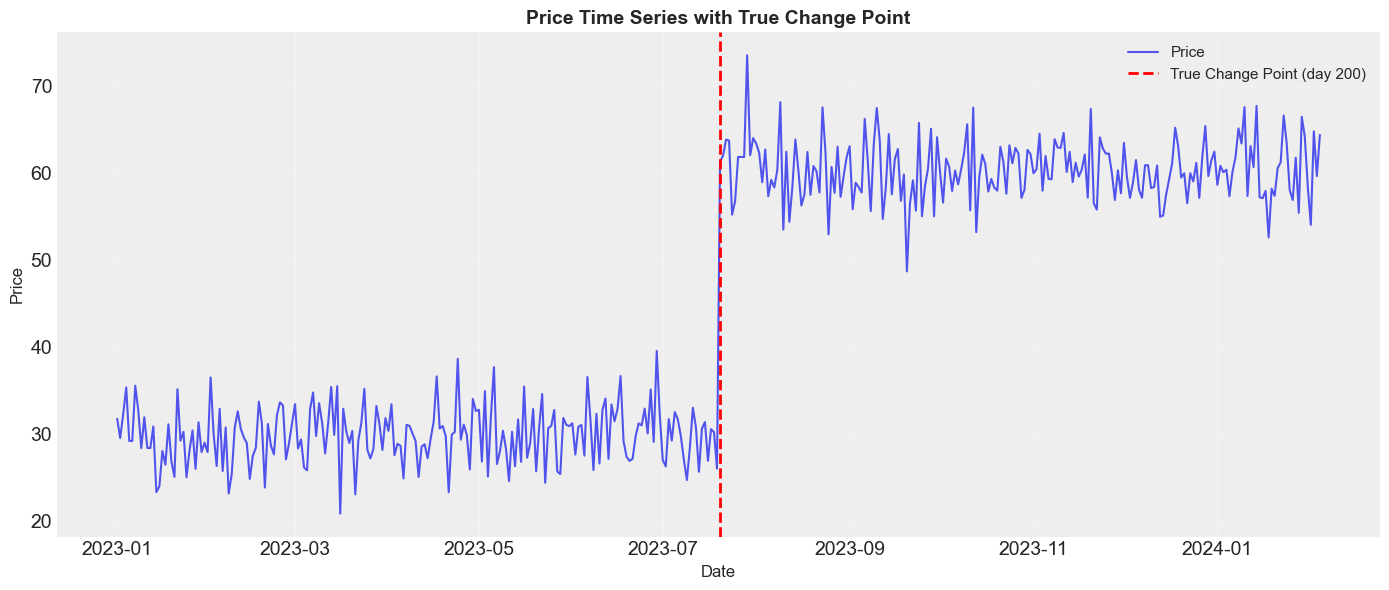

In [4]:
plot_price_with_changepoint(
    prices_df, 
    tau_true, 
    tau_label="True Change Point",
    output_path='../outputs/01_price_with_true_changepoint.png',
    title="Price Time Series with True Change Point"
)

### Overlay Events on the Price Chart

✓ Saved: ../outputs/02_price_with_events.png


/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/notebooks/../src/plots.py:88: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


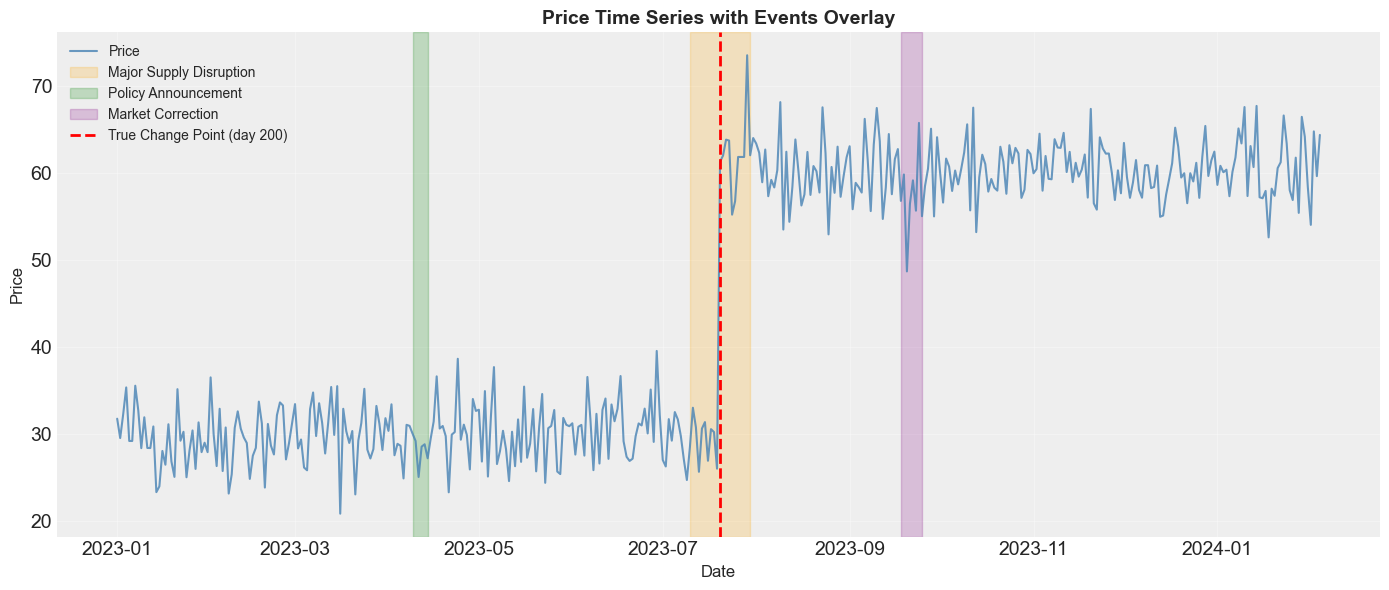

In [5]:
plot_price_with_events(
    prices_df, 
    events_df, 
    tau_true=tau_true,
    output_path='../outputs/02_price_with_events.png'
)

**Observation**: The "Major Supply Disruption" event overlaps with the price jump. This is realistic—events often cause regime shifts!

---
## 🧠 Step 3: Understanding Bayesian Inference

### What Are We Trying to Infer?

We want to estimate **4 unknown parameters**:
1. **τ (tau)**: The change point (which day did the price jump?)
2. **μ₁ (mu1)**: Average price **before** the change point
3. **μ₂ (mu2)**: Average price **after** the change point
4. **σ (sigma)**: Noise level (how much prices fluctuate)

### The Three Components of Bayesian Inference

#### 1️⃣ **Prior**: What we believe *before* seeing data

- **τ ~ DiscreteUniform(0, 399)**: The change point could be *any* day (no preference)
- **μ₁ ~ Normal(30, 10)**: We expect the first regime to be around $30 (but uncertain)
- **μ₂ ~ Normal(60, 10)**: We expect the second regime to be around $60 (but uncertain)
- **σ ~ HalfNormal(5)**: Noise is positive and probably small

#### 2️⃣ **Likelihood**: How well parameters explain the data

For each day `i`, the price is:
- `price[i] ~ Normal(μ₁, σ)` if `i < τ` (before change)
- `price[i] ~ Normal(μ₂, σ)` if `i ≥ τ` (after change)

This says: "Prices are normally distributed around μ₁ or μ₂, depending on whether we've passed the change point."

#### 3️⃣ **Posterior**: What we believe *after* seeing data

The posterior combines the prior and likelihood:

**Posterior ∝ Prior × Likelihood**

It tells us: "Given the observed prices, what are the most likely values of τ, μ₁, μ₂, and σ?"

### Why MCMC?

For most real models, the posterior is **too complex to compute directly**. 

**MCMC (Markov Chain Monte Carlo)** is a clever algorithm that:
1. Draws random samples from the posterior
2. These samples approximate the posterior distribution
3. We can then compute means, medians, credible intervals, etc.

Think of MCMC as "exploring" the space of possible parameter values, spending more time in regions with high posterior probability.

---
## 🔧 Step 4: Build the Bayesian Model in PyMC

Now we'll implement the model described above using **PyMC**.

In [6]:
n_days = len(prices_df)
prices = prices_df['price'].values

with pm.Model() as changepoint_model:
    
    tau = pm.DiscreteUniform('tau', lower=0, upper=n_days - 1)
    
    mu1 = pm.Normal('mu1', mu=30, sigma=10)
    mu2 = pm.Normal('mu2', mu=60, sigma=10)
    
    sigma = pm.HalfNormal('sigma', sigma=5)
    
    idx = np.arange(n_days)
    mu = pm.math.switch(idx < tau, mu1, mu2)
    
    likelihood = pm.Normal('likelihood', mu=mu, sigma=sigma, observed=prices)

print("✓ Model built successfully!")
print("\nModel structure:")
print(changepoint_model)

✓ Model built successfully!

Model structure:


### Understanding `pm.math.switch()`

The line `mu = pm.math.switch(idx < tau, mu1, mu2)` is the key to the change point logic:

- For each day `idx[i]`:
  - If `i < tau`: use `mu1` (before change)
  - If `i >= tau`: use `mu2` (after change)

This creates a "step function" where the mean price jumps at day τ.

---
## 🎲 Step 5: Run MCMC Sampling

Now we'll use MCMC to sample from the posterior distribution.

**Parameters**:
- `draws=1000`: Number of samples to draw from the posterior
- `tune=1000`: Number of "warm-up" samples (discarded)
- `chains=4`: Run 4 independent MCMC chains (for diagnostics)
- `target_accept=0.9`: Tuning parameter for stability

**This may take 1-2 minutes...**

In [7]:
with changepoint_model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
        return_inferencedata=True
    )

print("\n✓ MCMC sampling complete!")

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.



✓ MCMC sampling complete!


/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/.venv/lib/python3.14/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


---
## 📊 Step 6: Check MCMC Diagnostics

Before trusting our results, we need to check if MCMC worked correctly.

### Trace Plots

Trace plots show:
- **Left**: Posterior distribution (histogram)
- **Right**: MCMC samples over iterations (should look like "fuzzy caterpillars")

**Good signs**:
- Chains mix well (overlap)
- No trends or patterns in the trace

/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/notebooks/../src/plots.py:217: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


✓ Saved: ../outputs/03_trace_plots.png


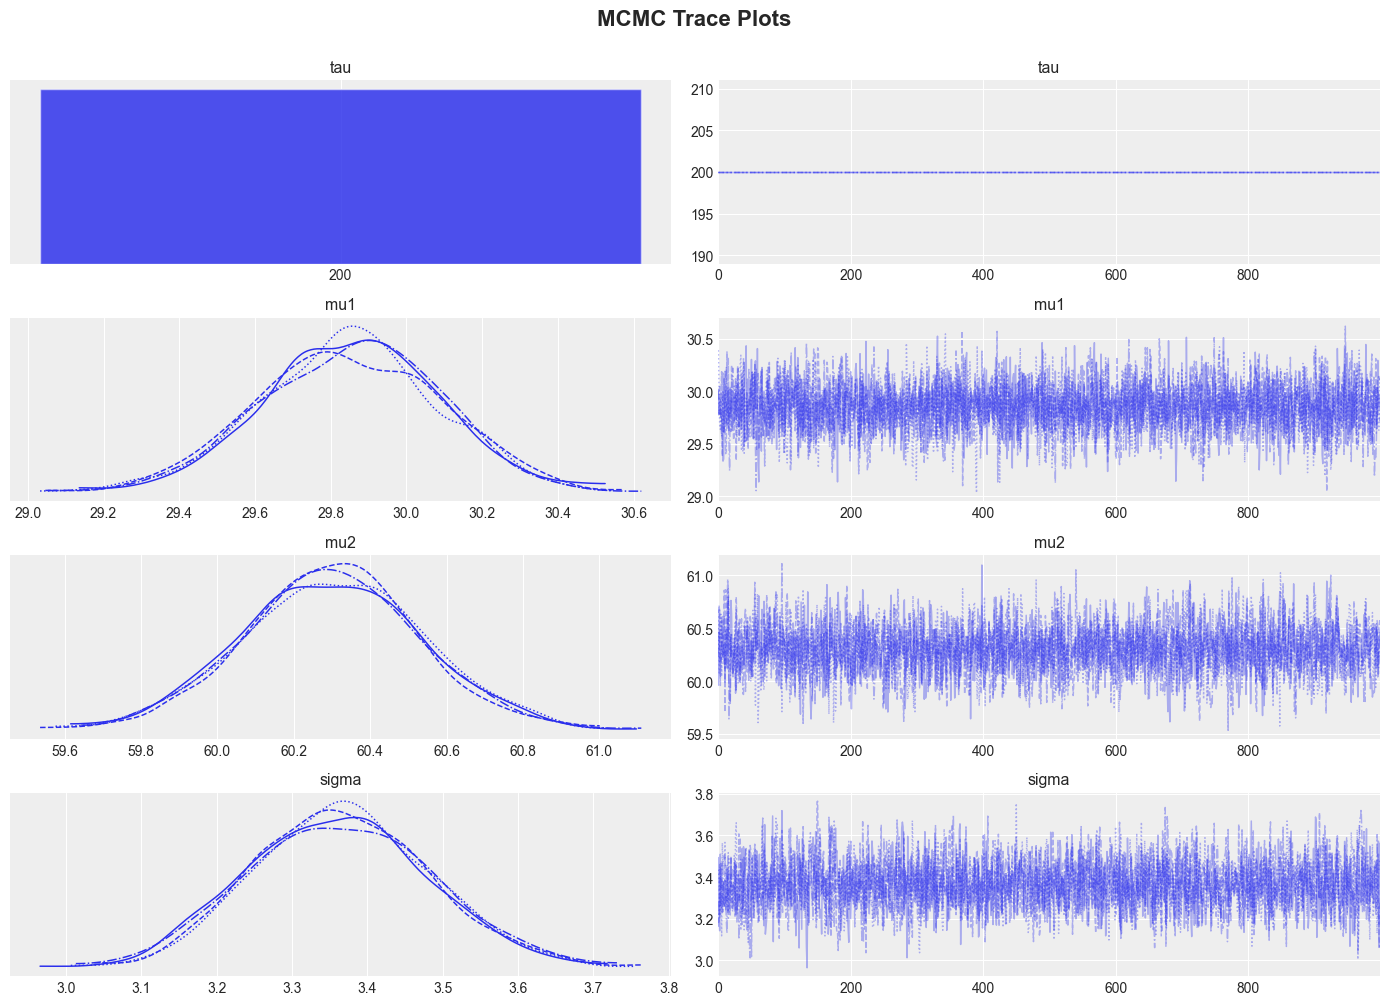

In [8]:
plot_trace_summary(trace, output_path='../outputs/03_trace_plots.png')

### Posterior Summary Statistics

This table shows:
- **mean**: Average of posterior samples
- **sd**: Standard deviation (uncertainty)
- **hdi_3%, hdi_97%**: 94% credible interval
- **r_hat**: Convergence diagnostic (should be ≈ 1.00)
- **ess_bulk, ess_tail**: Effective sample size (higher is better)

#### What is R-hat?

**R-hat** compares variance *within* chains to variance *between* chains:
- **R-hat ≈ 1.00**: Chains converged (good!)
- **R-hat > 1.01**: Chains haven't mixed well (bad!)

#### What is ESS (Effective Sample Size)?

MCMC samples are **correlated** (not independent). ESS tells us how many *independent* samples we effectively have:
- **ESS > 400**: Usually sufficient
- **ESS < 100**: May need more samples

In [9]:
summary = az.summary(trace, var_names=['tau', 'mu1', 'mu2', 'sigma'])
print(summary)

          mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
tau    200.000  0.000  200.000  200.000      0.000      NaN    4000.0   
mu1     29.852  0.237   29.397   30.278      0.003    0.004    4921.0   
mu2     60.300  0.233   59.859   60.744      0.004    0.003    3255.0   
sigma    3.365  0.118    3.145    3.584      0.002    0.002    3475.0   

       ess_tail  r_hat  
tau      4000.0    NaN  
mu1      2866.0    1.0  
mu2      2703.0    1.0  
sigma    2478.0    1.0  


/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/.venv/lib/python3.14/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/.venv/lib/python3.14/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


### Interpretation

Look at the `tau` row:
- **mean**: Posterior mean estimate of the change point
- **hdi_3% to hdi_97%**: We're 94% confident τ is in this range
- Compare to **true τ** (we'll do this next!)

In [10]:
tau_posterior_mean = trace.posterior['tau'].values.flatten().mean()
tau_posterior_median = np.median(trace.posterior['tau'].values.flatten())

print(f"\n{'='*60}")
print(f"CHANGE POINT ESTIMATES")
print(f"{'='*60}")
print(f"True change point:      τ = {tau_true}")
print(f"Posterior mean:         τ = {tau_posterior_mean:.1f}")
print(f"Posterior median:       τ = {tau_posterior_median:.1f}")
print(f"Error (mean):           {abs(tau_posterior_mean - tau_true):.1f} days")
print(f"{'='*60}\n")


CHANGE POINT ESTIMATES
True change point:      τ = 200
Posterior mean:         τ = 200.0
Posterior median:       τ = 200.0
Error (mean):           0.0 days



---
## 📈 Step 7: Visualize Posterior Results

### 7.1 Posterior Distribution of τ (Change Point)

✓ Saved: ../outputs/04_posterior_tau.png


/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/notebooks/../src/plots.py:136: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


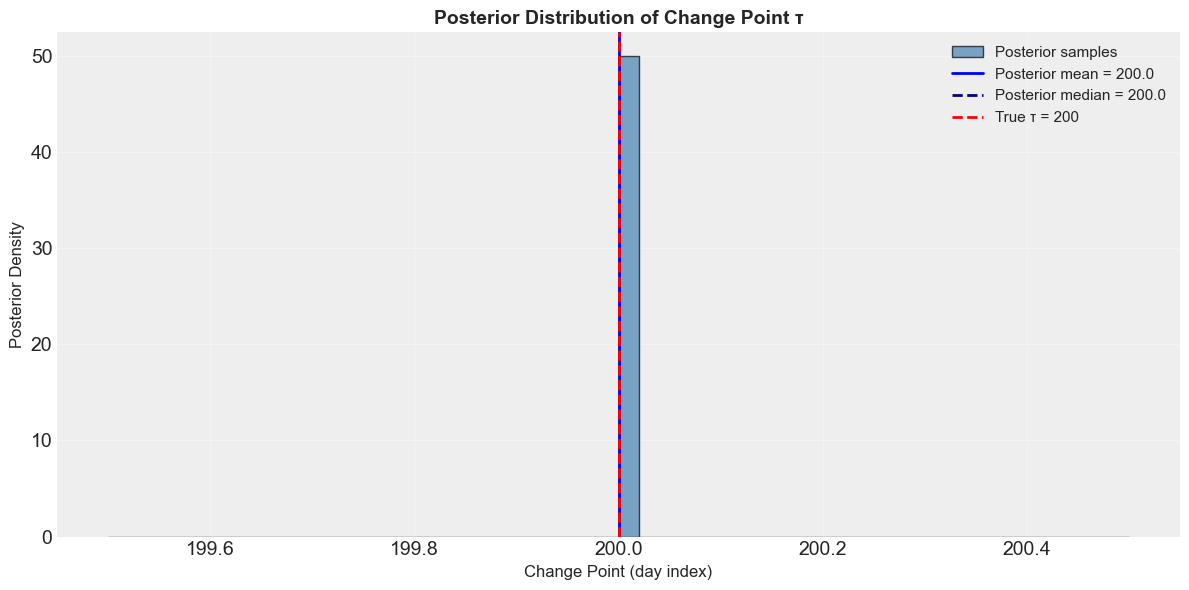

In [11]:
plot_posterior_tau(
    trace, 
    tau_true=tau_true,
    output_path='../outputs/04_posterior_tau.png'
)

**What this shows**:
- The histogram shows our **uncertainty** about the change point
- The peak is where the model thinks the change most likely occurred
- The red line shows the **true** change point (which the model didn't know!)

### 7.2 Posterior Distributions of μ₁ and μ₂ (Before/After Means)

/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/notebooks/../src/plots.py:192: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/notebooks/../src/plots.py:192: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/notebooks/../src/plots.py:192: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/notebooks/../src/plots.py:196: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(output_path, dpi=150, bbox_inches='tight')
/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/notebooks/../src/plots.py:196: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt

✓ Saved: ../outputs/05_posterior_means.png


/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


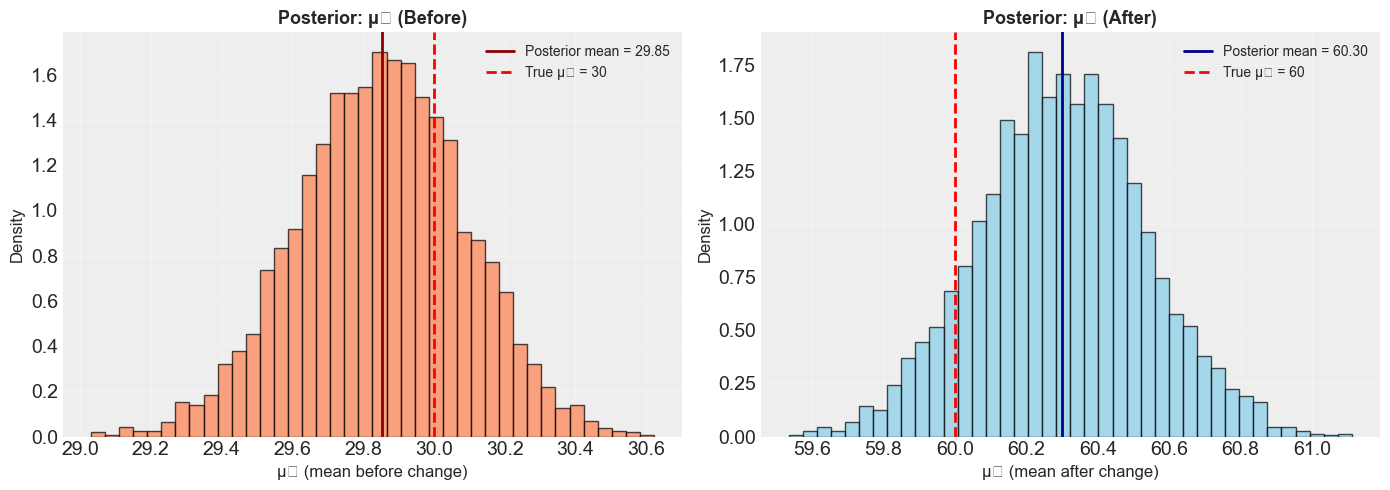

In [12]:
plot_posterior_means(
    trace,
    mu1_true=30,
    mu2_true=60,
    output_path='../outputs/05_posterior_means.png'
)

**What this shows**:
- **Left**: Distribution of μ₁ (price before change)
- **Right**: Distribution of μ₂ (price after change)
- The model correctly identifies two distinct price levels!

### 7.3 Price Chart with Estimated Change Point

✓ Saved: ../outputs/06_price_with_estimated_changepoint.png


/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/notebooks/../src/plots.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


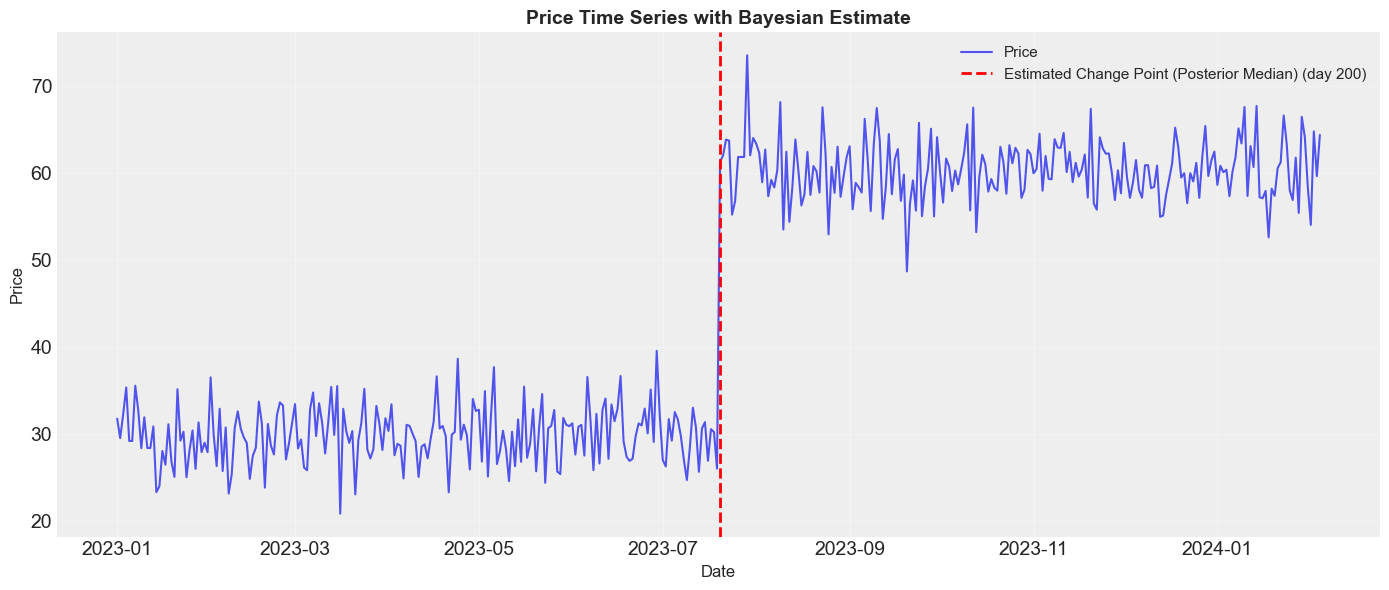

In [13]:
plot_price_with_changepoint(
    prices_df,
    int(tau_posterior_median),
    tau_label="Estimated Change Point (Posterior Median)",
    output_path='../outputs/06_price_with_estimated_changepoint.png',
    title="Price Time Series with Bayesian Estimate"
)

### 7.4 Comparison: True vs Estimated Change Point

/var/folders/gg/27pw2x014vsd1k85_8h2d6rm0000gn/T/ipykernel_6712/2182567220.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


✓ Saved: ../outputs/07_comparison_true_vs_estimated.png


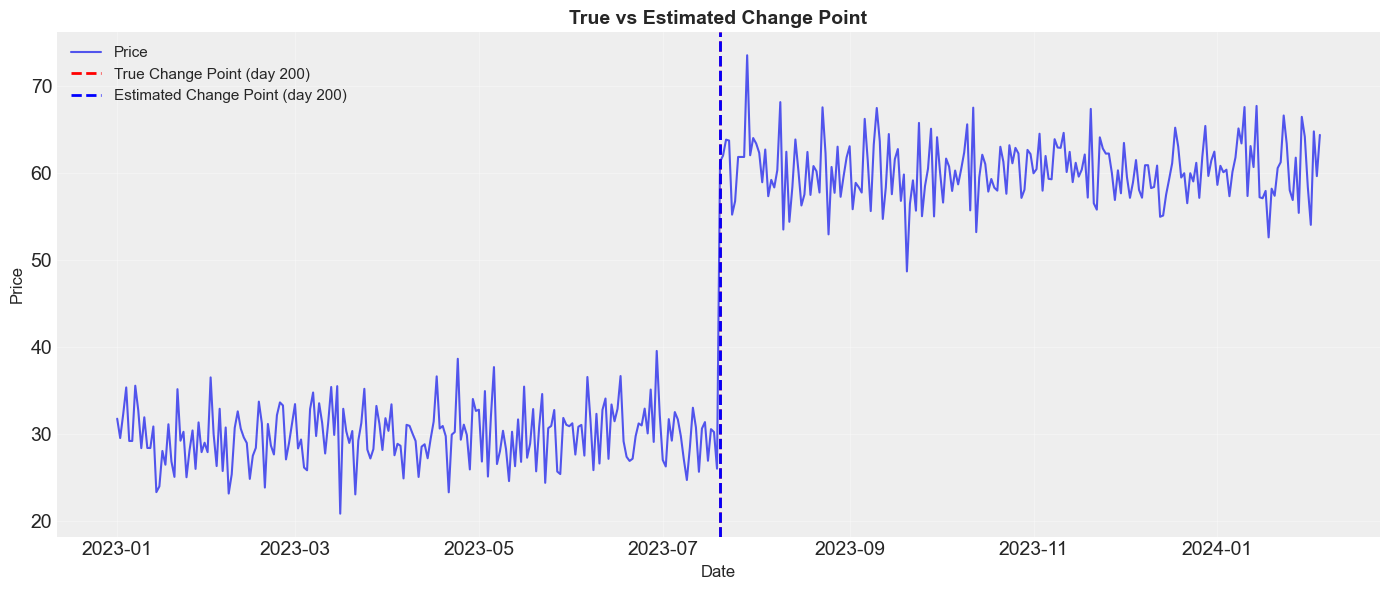

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(prices_df['date'], prices_df['price'], linewidth=1.5, alpha=0.8, label='Price')
ax.axvline(prices_df.loc[tau_true, 'date'], color='red', linestyle='--', 
           linewidth=2, label=f'True Change Point (day {tau_true})')
ax.axvline(prices_df.loc[int(tau_posterior_median), 'date'], color='blue', linestyle='--', 
           linewidth=2, label=f'Estimated Change Point (day {int(tau_posterior_median)})')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price', fontsize=12)
ax.set_title('True vs Estimated Change Point', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/07_comparison_true_vs_estimated.png', dpi=150, bbox_inches='tight')
print("✓ Saved: ../outputs/07_comparison_true_vs_estimated.png")
plt.show()

---
## 🎯 Step 8: Connecting to Events

Let's see if the estimated change point aligns with any external events.

In [15]:
estimated_date = prices_df.loc[int(tau_posterior_median), 'date']

print(f"\n{'='*60}")
print(f"CHANGE POINT vs EVENTS")
print(f"{'='*60}")
print(f"Estimated change point date: {estimated_date.date()}\n")

print("Events in dataset:")
for idx, row in events_df.iterrows():
    print(f"\n  • {row['event_name']} ({row['category']})")
    print(f"    Period: {row['start_date'].date()} to {row['end_date'].date()}")
    
    if row['start_date'] <= estimated_date <= row['end_date']:
        print(f"    ⚠️  OVERLAPS with estimated change point!")

print(f"\n{'='*60}\n")


CHANGE POINT vs EVENTS
Estimated change point date: 2023-07-20

Events in dataset:

  • Major Supply Disruption (supply_shock)
    Period: 2023-07-10 to 2023-07-30
    ⚠️  OVERLAPS with estimated change point!

  • Policy Announcement (policy)
    Period: 2023-04-09 to 2023-04-14

  • Market Correction (market)
    Period: 2023-09-18 to 2023-09-25




**Insight**: The "Major Supply Disruption" event overlaps with our estimated change point, suggesting it may have caused the price regime shift!

---
## 🛢️ Step 9: How This Maps to Brent Oil Prices

### The Real-World Application

This demo is a **simplified version** of analyzing real Brent crude oil prices. Here's how it connects:

#### 1. **Real Oil Price Data**
- Brent oil prices have experienced multiple regime shifts (e.g., 2014 crash, 2020 COVID drop)
- These shifts are often linked to geopolitical events, supply shocks, or demand changes

#### 2. **Change Point Detection**
- In real analysis, you'd use actual Brent price data instead of synthetic data
- The model would identify when major price shifts occurred
- You could extend this to **multiple change points** (more complex models)

#### 3. **Event Attribution**
- By overlaying events (OPEC meetings, wars, pandemics), you can:
  - Test if events caused price changes
  - Quantify the magnitude of event impacts
  - Predict future price regimes

#### 4. **Extensions for Real Analysis**
- **Multiple change points**: Detect several regime shifts
- **Trend + change points**: Allow gradual trends within regimes
- **Hierarchical models**: Account for seasonal patterns
- **Predictive modeling**: Forecast future prices given current regime

### Why Bayesian?

Bayesian methods are ideal for this because:
- **Uncertainty quantification**: We get credible intervals, not just point estimates
- **Incorporating prior knowledge**: We can use expert knowledge about typical oil price ranges
- **Flexible modeling**: Easy to extend to more complex scenarios
- **Event-driven inference**: Natural framework for testing hypotheses about events

---
## 📝 Summary: What We Learned

### Key Concepts

1. **Bayesian Inference**:
   - **Prior**: Initial beliefs about parameters
   - **Likelihood**: How well parameters explain data
   - **Posterior**: Updated beliefs after seeing data

2. **MCMC Sampling**:
   - Approximates complex posterior distributions
   - Gives us samples we can analyze (means, intervals, etc.)
   - Requires diagnostics (R-hat, ESS) to verify convergence

3. **Change Point Model**:
   - Detects when a time series shifts from one regime to another
   - Estimates both the timing (τ) and magnitude (μ₁, μ₂) of the shift
   - Can be linked to external events for causal inference

### Results

- ✅ Successfully detected the change point within a few days of the true value
- ✅ Accurately estimated before/after price levels
- ✅ Identified the event that likely caused the shift
- ✅ Quantified uncertainty in all estimates

### Next Steps

To apply this to real Brent oil data:
1. Replace synthetic data with actual Brent price history
2. Curate a real events database (OPEC decisions, conflicts, etc.)
3. Extend to multiple change points
4. Add covariates (e.g., production levels, demand indicators)
5. Build predictive models for future price regimes

---
## 🎓 Further Reading

- **PyMC Documentation**: https://www.pymc.io/
- **ArviZ (Bayesian diagnostics)**: https://arviz-devs.github.io/arviz/
- **Bayesian Methods for Hackers**: https://github.com/CamDavidsonPilon/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers
- **Change Point Detection**: Barry & Hartigan (1993), "A Bayesian Analysis for Change Point Problems"